In [1]:
# ============================================================
# SPEECH EMOTION-AWARE CONVERSATIONAL AGENT
# Speech Emotion-Based Response Generation
# ============================================================

!pip -q install librosa soundfile scikit-learn seaborn datasets transformers accelerate

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", DEVICE)

PyTorch: 2.11.0+cpu
GPU available: False
Using: cpu


Download RAVDESS

In [3]:
from datasets import load_dataset

dataset = load_dataset(
    "xbgoose/ravdess",
    split="train"
)

print(dataset)

README.md:   0%|          | 0.00/669 [00:00<?, ?B/s]

data/train-00000-of-00002-94d632c9f1f51b(…): reconstructing file:   0%|          |  0.00B /  167MB            

data/train-00000-of-00002-94d632c9f1f51b(…): downloading bytes:           |  0.00B            

data/train-00001-of-00002-bcaf733d4b46d6(…): reconstructing file:   0%|          |  0.00B /  158MB            

data/train-00001-of-00002-bcaf733d4b46d6(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1440 [00:00<?, ? examples/s]

Dataset({
    features: ['audio', 'modality', 'vocal_channel', 'emotion', 'emotional_intensity', 'statement', 'repetition', 'actor', 'gender'],
    num_rows: 1440
})


In [4]:
print(dataset.column_names)
print(dataset.features)

['audio', 'modality', 'vocal_channel', 'emotion', 'emotional_intensity', 'statement', 'repetition', 'actor', 'gender']
{'audio': Audio(sampling_rate=None, decode=True, stream_index=None), 'modality': Value('string'), 'vocal_channel': Value('string'), 'emotion': Value('string'), 'emotional_intensity': Value('string'), 'statement': Value('string'), 'repetition': Value('string'), 'actor': Value('int64'), 'gender': Value('string')}


3. Create our 4 emotion classes

In [5]:
EMOTIONS = ["angry", "happy", "sad", "neutral"]

emotion_to_id = {
    "angry": 0,
    "happy": 1,
    "sad": 2,
    "neutral": 3
}

id_to_emotion = {
    v: k for k, v in emotion_to_id.items()
}

print(emotion_to_id)

{'angry': 0, 'happy': 1, 'sad': 2, 'neutral': 3}


In [6]:
filtered_data = dataset.filter(
    lambda x: x["emotion"] in EMOTIONS
)

print("Original samples:", len(dataset))
print("Filtered samples:", len(filtered_data))

Filter:   0%|          | 0/1440 [00:00<?, ? examples/s]

Original samples: 1440
Filtered samples: 672


In [7]:
labels = filtered_data["emotion"]

print(pd.Series(labels).value_counts())

angry      192
sad        192
happy      192
neutral     96
Name: count, dtype: int64


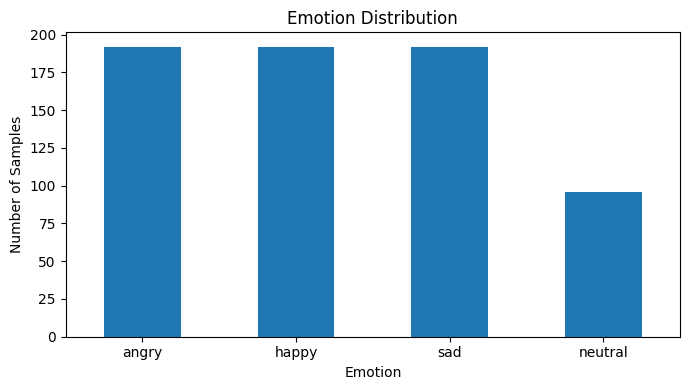

In [8]:
plt.figure(figsize=(7, 4))

pd.Series(labels).value_counts().reindex(EMOTIONS).plot(kind="bar")

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

4. Audio preprocessing

In [9]:
SR = 16000
DURATION = 4
MAX_LENGTH = SR * DURATION

N_MELS = 64

In [10]:
def preprocess_audio(audio_array, original_sr):
    """
    Convert audio to mono, resample to 16kHz,
    normalize and pad/truncate to fixed length.
    """

    audio_array = np.asarray(audio_array, dtype=np.float32)

    # Mono
    if audio_array.ndim > 1:
        audio_array = np.mean(audio_array, axis=0)

    # Resampling
    if original_sr != SR:
        audio_array = librosa.resample(
            audio_array,
            orig_sr=original_sr,
            target_sr=SR
        )

    # Normalize
    max_val = np.max(np.abs(audio_array))

    if max_val > 0:
        audio_array = audio_array / max_val

    # Fixed length
    if len(audio_array) < MAX_LENGTH:
        audio_array = np.pad(
            audio_array,
            (0, MAX_LENGTH - len(audio_array))
        )
    else:
        audio_array = audio_array[:MAX_LENGTH]

    return audio_array

5. Extract Mel Spectrogram

In [11]:
def extract_mel_spectrogram(audio_array):

    mel = librosa.feature.melspectrogram(
        y=audio_array,
        sr=SR,
        n_mels=N_MELS,
        n_fft=1024,
        hop_length=512
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    # Normalize
    mel_db = (mel_db - mel_db.mean()) / (
        mel_db.std() + 1e-8
    )

    return mel_db.astype(np.float32)

testing

In [12]:
sample = filtered_data[0]

audio = sample["audio"]["array"]
sample_sr = sample["audio"]["sampling_rate"]

audio_processed = preprocess_audio(
    audio,
    sample_sr
)

mel = extract_mel_spectrogram(
    audio_processed
)

print("Audio shape:", audio_processed.shape)
print("Mel shape:", mel.shape)

Audio shape: (64000,)
Mel shape: (64, 126)


Visualize

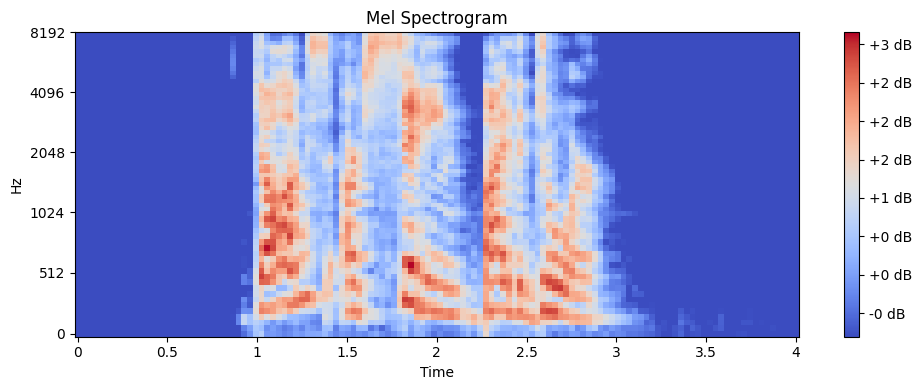

In [13]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mel,
    sr=SR,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()

6. Prepare the dataset

In [14]:
X = []
y = []
actors = []

for item in tqdm(filtered_data):

    audio = item["audio"]["array"]
    sr = item["audio"]["sampling_rate"]

    processed = preprocess_audio(
        audio,
        sr
    )

    mel = extract_mel_spectrogram(
        processed
    )

    X.append(mel)
    y.append(
        emotion_to_id[item["emotion"]]
    )

    actors.append(item["actor"])

X = np.array(X)
y = np.array(y)
actors = np.array(actors)

print("X:", X.shape)
print("y:", y.shape)

  0%|          | 0/672 [00:00<?, ?it/s]

X: (672, 64, 126)
y: (672,)


7. Speaker-independent split

We don't want the same actor appearing in both training and testing.

RAVDESS contains 24 actors, so we'll split actors rather than randomly splitting utterances. The dataset is balanced across 24 professional actors.

In [15]:
unique_actors = np.unique(actors)

train_actors, temp_actors = train_test_split(
    unique_actors,
    test_size=0.30,
    random_state=42
)

val_actors, test_actors = train_test_split(
    temp_actors,
    test_size=0.50,
    random_state=42
)

print("Train actors:", train_actors)
print("Validation actors:", val_actors)
print("Test actors:", test_actors)

Train actors: [22  6  3 13 16  4  5 23 18 21 24  8 11 15 20  7]
Validation actors: [ 1 12 19 14]
Test actors: [17 10  9  2]


creating masks

In [16]:
train_mask = np.isin(actors, train_actors)
val_mask = np.isin(actors, val_actors)
test_mask = np.isin(actors, test_actors)

X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (448, 64, 126)
Validation: (112, 64, 126)
Test: (112, 64, 126)


8. PyTorch Dataset

In [17]:
class EmotionDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):

        # CNN expects:
        # [channels, height, width]

        x = self.X[idx].unsqueeze(0)

        return x, self.y[idx]

In [18]:
BATCH_SIZE = 32

train_dataset = EmotionDataset(
    X_train,
    y_train
)

val_dataset = EmotionDataset(
    X_val,
    y_val
)

test_dataset = EmotionDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

9. CNN-BiLSTM model

In [19]:
class CNNBiLSTM(nn.Module):

    def __init__(self, num_classes=4):

        super().__init__()

        self.cnn = nn.Sequential(

            nn.Conv2d(
                1, 32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.lstm = nn.LSTM(
            input_size=128 * 8,
            hidden_size=128,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.4)

        self.fc = nn.Linear(
            256,
            num_classes
        )

    def forward(self, x):

        x = self.cnn(x)

        # [batch, channels, height, time]

        batch, channels, height, time = x.shape

        # Rearrange for LSTM
        x = x.permute(
            0, 3, 1, 2
        )

        x = x.reshape(
            batch,
            time,
            channels * height
        )

        x, _ = self.lstm(x)

        # Last timestep
        x = x[:, -1, :]

        x = self.dropout(x)

        return self.fc(x)

initialize


In [20]:
model = CNNBiLSTM(
    num_classes=4
).to(DEVICE)

print(model)

CNNBiLSTM(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(1024, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=4, bias=True)
)


10. Training configuration

In [21]:
LEARNING_RATE = 1e-3
EPOCHS = 20

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=2,
    factor=0.5
)

11. Training loop

In [22]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += (
            loss.item() *
            y_batch.size(0)
        )

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

    return (
        running_loss / total,
        correct / total
    )

12. Validation

In [23]:
def evaluate(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            running_loss += (
                loss.item() *
                y_batch.size(0)
            )

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == y_batch
            ).sum().item()

            total += y_batch.size(0)

            all_preds.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                y_batch.cpu().numpy()
            )

    return (
        running_loss / total,
        correct / total,
        np.array(all_labels),
        np.array(all_preds)
    )

13. Train

In [24]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_emotion_model.pt"
        )

Epoch 01/20 | Train Loss: 1.3410 | Train Acc: 0.3504 | Val Loss: 1.3188 | Val Acc: 0.2857
Epoch 02/20 | Train Loss: 1.2836 | Train Acc: 0.3973 | Val Loss: 1.2762 | Val Acc: 0.3839
Epoch 03/20 | Train Loss: 1.2167 | Train Acc: 0.4754 | Val Loss: 1.2398 | Val Acc: 0.3750
Epoch 04/20 | Train Loss: 1.1182 | Train Acc: 0.5112 | Val Loss: 1.1657 | Val Acc: 0.3750
Epoch 05/20 | Train Loss: 1.0765 | Train Acc: 0.5201 | Val Loss: 1.1110 | Val Acc: 0.4821
Epoch 06/20 | Train Loss: 0.9572 | Train Acc: 0.5982 | Val Loss: 1.0901 | Val Acc: 0.4911
Epoch 07/20 | Train Loss: 0.8643 | Train Acc: 0.6362 | Val Loss: 1.0029 | Val Acc: 0.5804
Epoch 08/20 | Train Loss: 0.7925 | Train Acc: 0.6786 | Val Loss: 1.2624 | Val Acc: 0.4643
Epoch 09/20 | Train Loss: 0.8155 | Train Acc: 0.6652 | Val Loss: 0.9140 | Val Acc: 0.6071
Epoch 10/20 | Train Loss: 0.7199 | Train Acc: 0.6808 | Val Loss: 0.9161 | Val Acc: 0.5982
Epoch 11/20 | Train Loss: 0.6616 | Train Acc: 0.7232 | Val Loss: 1.0351 | Val Acc: 0.6071
Epoch 12/2

14. Loss curves

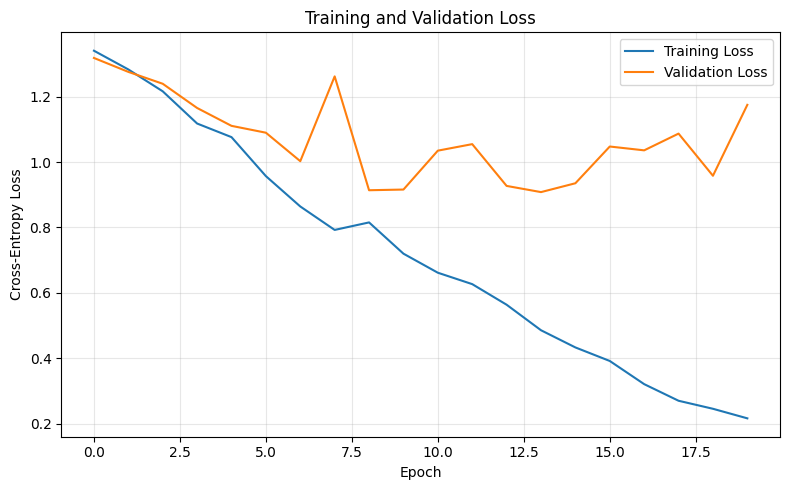

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "training_loss.png",
    dpi=200
)

plt.show()

15. Accuracy curve

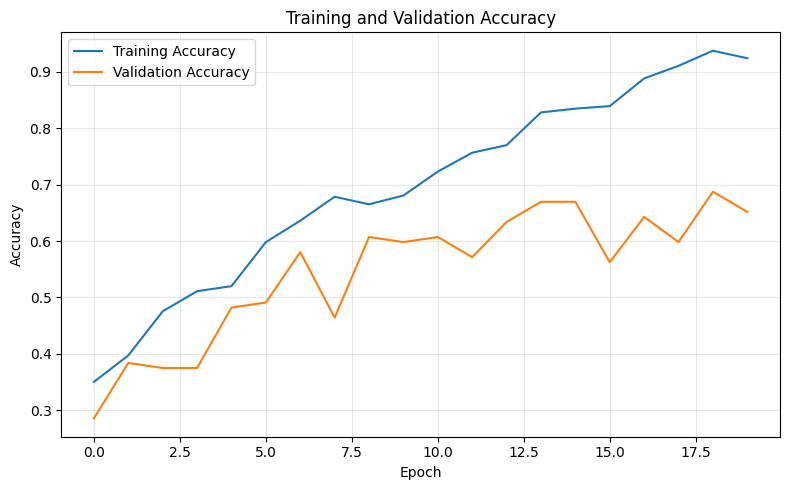

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "accuracy_curve.png",
    dpi=200
)

plt.show()

16. Test evaluation

In [27]:
model.load_state_dict(
    torch.load(
        "best_emotion_model.pt",
        map_location=DEVICE
    )
)

test_loss, test_acc, y_true, y_pred = evaluate(
    model,
    test_loader
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 1.0837249755859375
Test Accuracy: 0.5535714285714286


17. Classification report

In [28]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=EMOTIONS,
        digits=4
    )
)

              precision    recall  f1-score   support

       angry     1.0000    0.6250    0.7692        32
       happy     0.5526    0.6562    0.6000        32
         sad     0.4828    0.4375    0.4590        32
     neutral     0.2800    0.4375    0.3415        16

    accuracy                         0.5536       112
   macro avg     0.5788    0.5391    0.5424       112
weighted avg     0.6215    0.5536    0.5711       112



18. Confusion matrix

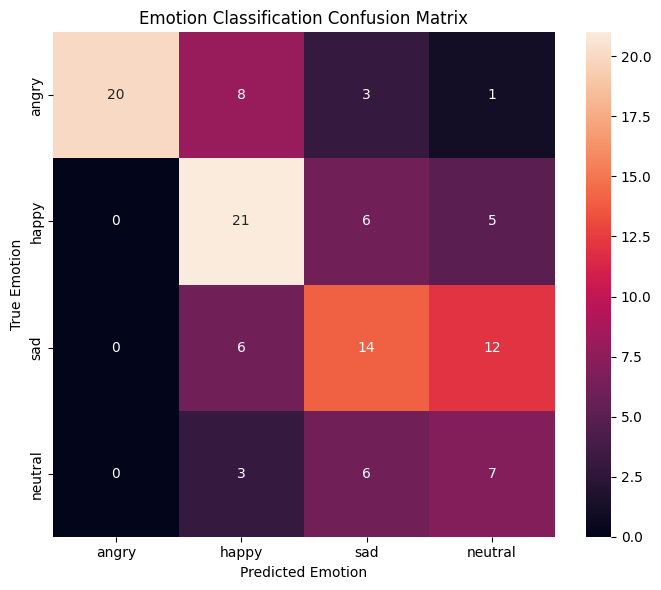

In [29]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=EMOTIONS,
    yticklabels=EMOTIONS
)

plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.title("Emotion Classification Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=200
)

plt.show()

19. Emotion prediction function

In [30]:
def predict_emotion(audio_array, sr):

    processed = preprocess_audio(
        audio_array,
        sr
    )

    mel = extract_mel_spectrogram(
        processed
    )

    tensor = torch.tensor(
        mel,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    tensor = tensor.to(DEVICE)

    model.eval()

    with torch.no_grad():

        logits = model(tensor)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predicted_id = logits.argmax(
            dim=1
        ).item()

    return (
        id_to_emotion[predicted_id],
        probabilities.cpu().numpy()[0]
    )

20. Test prediction

In [31]:
sample = filtered_data[10]

emotion, probabilities = predict_emotion(
    sample["audio"]["array"],
    sample["audio"]["sampling_rate"]
)

print("Predicted emotion:", emotion)

for emotion_name, probability in zip(
    EMOTIONS,
    probabilities
):
    print(
        f"{emotion_name:10s}: "
        f"{probability:.3f}"
    )

Predicted emotion: angry
angry     : 0.984
happy     : 0.012
sad       : 0.002
neutral   : 0.001


21. NOW the LLM component

In [32]:
def build_emotion_prompt(
    transcript,
    emotion
):

    prompt = f"""
You are an emotion-aware conversational assistant.

The user said:
"{transcript}"

The detected emotional state is:
{emotion}

Generate a response that:
1. Acknowledges the emotional state.
2. Is relevant to what the user said.
3. Uses an appropriate emotional tone.
4. Does not explicitly mention the emotion label.
5. Does not sound robotic.

Response:
"""

    return prompt

In [33]:
transcript = "I worked really hard but I still failed the exam."

emotion = "sad"

prompt = build_emotion_prompt(
    transcript,
    emotion
)

print(prompt)


You are an emotion-aware conversational assistant.

The user said:
"I worked really hard but I still failed the exam."

The detected emotional state is:
sad

Generate a response that:
1. Acknowledges the emotional state.
2. Is relevant to what the user said.
3. Uses an appropriate emotional tone.
4. Does not explicitly mention the emotion label.
5. Does not sound robotic.

Response:



22. LLM response generation

In [34]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="distilgpt2",
    device=0 if torch.cuda.is_available() else -1
)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [35]:
def generate_response(
    transcript,
    emotion
):

    prompt = build_emotion_prompt(
        transcript,
        emotion
    )

    result = generator(
        prompt,
        max_new_tokens=60,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        pad_token_id=generator.tokenizer.eos_token_id
    )

    generated = result[0]["generated_text"]

    return generated

In [36]:
response = generate_response(
    "I worked really hard but I still failed the exam.",
    "sad"
)

print(response)

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature', 'top_p', 'do_sample', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



You are an emotion-aware conversational assistant.

The user said:
"I worked really hard but I still failed the exam."

The detected emotional state is:
sad

Generate a response that:
1. Acknowledges the emotional state.
2. Is relevant to what the user said.
3. Uses an appropriate emotional tone.
4. Does not explicitly mention the emotion label.
5. Does not sound robotic.

Response:
"The user said:
"I have some feelings but I still failed the exam."
The user said:
"I think I did a lot of research and I think I've been a very good conversational assistant.
"I'm not sure if I can really see what the user


23. Showing why emotion conditioning matters

In [37]:
text = "I finally got the job!"

for emotion in [
    "happy",
    "sad",
    "angry"
]:

    print("=" * 60)

    print("Emotion:", emotion)

    print(
        generate_response(
            text,
            emotion
        )
    )

[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Emotion: happy


[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are an emotion-aware conversational assistant.

The user said:
"I finally got the job!"

The detected emotional state is:
happy

Generate a response that:
1. Acknowledges the emotional state.
2. Is relevant to what the user said.
3. Uses an appropriate emotional tone.
4. Does not explicitly mention the emotion label.
5. Does not sound robotic.

Response:
"I'm going to say that this is a simple question to answer, and I've just asked the user what I would like to know about the emotional state. I've just asked the user what I would like to know about the emotional state. I've just asked the user what I would like
Emotion: sad


[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are an emotion-aware conversational assistant.

The user said:
"I finally got the job!"

The detected emotional state is:
sad

Generate a response that:
1. Acknowledges the emotional state.
2. Is relevant to what the user said.
3. Uses an appropriate emotional tone.
4. Does not explicitly mention the emotion label.
5. Does not sound robotic.

Response:
1. Is emotional.
2. Is not emotion-aware.
3. Is not emotion-aware.
4. Is not emotional.
5. Is not emotional.
6. Is not emotion-aware.
7. Is not emotion-aware.
8. Is not
Emotion: angry

You are an emotion-aware conversational assistant.

The user said:
"I finally got the job!"

The detected emotional state is:
angry

Generate a response that:
1. Acknowledges the emotional state.
2. Is relevant to what the user said.
3. Uses an appropriate emotional tone.
4. Does not explicitly mention the emotion label.
5. Does not sound robotic.

Response:
"Oh my God! I don't think this is really a robot!"
The user said:
"You're a robot! I don't thi

end to end function tieing all up

In [38]:
def speech_to_emotion_aware_response(
    audio_array,
    sr,
    transcript
):

    # Step 1: Emotion recognition
    emotion, probabilities = predict_emotion(
        audio_array,
        sr
    )

    # Step 2: Generate response
    response = generate_response(
        transcript,
        emotion
    )

    return {
        "emotion": emotion,
        "probabilities": probabilities,
        "response": response
    }

In [39]:
sample = filtered_data[20]

result = speech_to_emotion_aware_response(
    sample["audio"]["array"],
    sample["audio"]["sampling_rate"],
    "I have been working on this project all night."
)

print("Detected Emotion:")
print(result["emotion"])

print("\nResponse:")
print(result["response"])

[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Detected Emotion:
angry

Response:

You are an emotion-aware conversational assistant.

The user said:
"I have been working on this project all night."

The detected emotional state is:
angry

Generate a response that:
1. Acknowledges the emotional state.
2. Is relevant to what the user said.
3. Uses an appropriate emotional tone.
4. Does not explicitly mention the emotion label.
5. Does not sound robotic.

Response:
"I am not sure how this is going to be done. I don't know what I'm going to do."
6. Is not trying to give the user a sense of what the user said.
7. Is not really trying to help the user understand what the user said.



25. Perplexity

In [40]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(
    "distilgpt2"
)

lm = AutoModelForCausalLM.from_pretrained(
    "distilgpt2"
).to(DEVICE)

def calculate_perplexity(text):

    inputs = tokenizer(
        text,
        return_tensors="pt"
    )

    input_ids = inputs["input_ids"].to(
        DEVICE
    )

    with torch.no_grad():

        outputs = lm(
            input_ids,
            labels=input_ids
        )

        loss = outputs.loss

    perplexity = torch.exp(loss)

    return perplexity.item()

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

In [42]:
text = """
I am disappointed because I worked very hard
but I did not get the result I expected.
"""

print(
    "Perplexity:",
    calculate_perplexity(text)
)

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Perplexity: 28.141368865966797


26. Saving results

In [43]:
os.makedirs("results", exist_ok=True)

# Move plots
import shutil

for file in [
    "training_loss.png",
    "accuracy_curve.png",
    "confusion_matrix.png"
]:

    if os.path.exists(file):
        shutil.copy(
            file,
            f"results/{file}"
        )

In [44]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted"
)

metrics = {
    "test_accuracy": test_acc,
    "test_loss": test_loss,
    "weighted_precision": precision,
    "weighted_recall": recall,
    "weighted_f1": f1
}

pd.DataFrame(
    [metrics]
).to_csv(
    "results/metrics.csv",
    index=False
)

print(metrics)

{'test_accuracy': 0.5535714285714286, 'test_loss': 1.0837249755859375, 'weighted_precision': 0.6215400570391497, 'weighted_recall': 0.5535714285714286, 'weighted_f1': 0.5711368199972758}


Save the model

In [45]:
os.makedirs("models", exist_ok=True)

torch.save(
    model.state_dict(),
    "models/emotion_cnn_bilstm.pt"
)